In [1]:
import sys
sys.path.append("../source")

In [2]:
import numpy as np
import math
import matplotlib.pyplot as plt
import pylab
from tqdm import trange
import scipy
import scipy.stats as stats
from scipy.stats import bernoulli
import matplotlib as mp
from numba import njit
from project_lib import *
import pandas as pd

In [38]:
from enum import Enum, auto

class Type(Enum):
    ONE_BETA = "ONE_BETA"
    ONE_EXPON = "ONE_EXPON"
    BOTH_BETA_EXPON = "BOTH_BETA_EXPON"
    BOTH_BETA = "BOTH_BETA"
    BOTH_EXPON = "BOTH_EXPON"


def init_consensus_data(consensus_data, experiment, N, alpha, beta, expon_alpha, R, type:Type):
    if not ((consensus_data['N'] == N) 
            & (consensus_data['alpha'] == alpha) 
            & (consensus_data['beta'] == beta)
            & (consensus_data['expon_alpha'] == expon_alpha)
            & (consensus_data['type'] == type.value) 
            & (round(consensus_data['eps'],2) == round(R,2))
            ).any():
        consensus_data.at[experiment, "N"] = N
        consensus_data.at[experiment, "alpha"] = alpha
        consensus_data.at[experiment, "beta"] = beta
        consensus_data.at[experiment, "expon_alpha"] = expon_alpha
        consensus_data.at[experiment, "eps"] = round(R,2)
        consensus_data.at[experiment, "consensus_x"] = 0
        consensus_data.at[experiment, "consensus_y"] = 0
        consensus_data.at[experiment, "consensus_probabity"] =0
        consensus_data.at[experiment, "simulation_time"] =0
        consensus_data.at[experiment, "simulation_count"] = 0
        consensus_data.at[experiment, "type"] = type.value

def update_beta_distrib_consensus_data(consensus_data, experiment, res_arr_fast):
    consensus_data.at[experiment, "consensus_x"] += res_arr_fast[-1, 0, 0]
    consensus_data.at[experiment, "consensus_y"] += res_arr_fast[-1, 0, 1]
    consensus_data.at[experiment, "consensus_probabity"] +=1
    consensus_data.at[experiment, "simulation_time"] +=res_arr_fast.shape[0]
    

dtypes = {
    'N': np.int64,
    'alpha': np.float64,
    'beta': np.float64,
    'eps': np.float64,
    'consensus_x': np.float64,
    'consensus_y': np.float64,
    'consensus_probabity': np.float64,
    'simulation_time': np.int64,
    'simulation_count': np.int64,
    'type': str

}

def beta_distrib_ab2Esigma(alpha, beta):
    return alpha/(alpha+beta), alpha*beta/((alpha+beta+1)*(alpha+beta)**2)
def beta_distrib_Esigma2ab(E, sigma):
    alpha = (E**2 - E**3) / sigma - E
    beta = (E - E**2) / sigma - 1 - ((E**2 - E**3) / sigma - E)
    return alpha, beta

In [19]:
dtypes = {
    'N': np.int64,
    'alpha': np.float64,
    'beta': np.float64,
    'eps': np.float64,
    'consensus_x': np.float64,
    'consensus_y': np.float64,
    'consensus_probabity': np.float64,
    'simulation_time': np.int64,
    'simulation_count': np.int64
}
beta_distib_consensus_data = pd.read_csv('beta_distib_consensus_data.csv', sep=";", dtype=dtypes)
beta_distib_consensus_data

,N,alpha,beta,eps,consensus_x,consensus_y,consensus_probabity,simulation_time,simulation_count
0,2500,0.50,0.50,0.15,0.000000,0.000000,0.0,0,10
1,2500,1.00,1.00,0.15,0.000000,0.000000,0.0,0,10
2,2500,1.50,1.50,0.15,0.000000,0.000000,0.0,0,10
3,2500,2.00,2.00,0.15,0.000000,0.000000,0.0,0,10
4,2500,2.50,2.50,0.15,4.003755,3.964977,8.0,153,10
...,...,...,...,...,...,...,...,...,...
2577,50,0.92,1.09,1.00,182.037151,183.435073,400.0,1200,400
2578,50,0.80,1.39,1.00,146.209713,143.782989,400.0,1196,400
2579,50,0.72,2.17,1.00,98.558097,99.524942,400.0,1056,400
2580,50,0.78,6.21,1.00,44.872463,44.632089,400.0,800,400


In [29]:
unif_dtypes = {
    'N': np.int64,
    'eps': np.float64,
    'consensus_x': np.float64,
    'consensus_y': np.float64,
    'consensus_probabity': np.float64,
    'simulation_time': np.int64,
    'simulation_count': np.int64
}
unif_data = pd.read_csv('unif_distib_consensus_data.csv', sep=";", dtype=unif_dtypes)

In [53]:
def expon_distrib_a2Esigma(alpha):
    e2ma = np.exp(-alpha)
    E = 1 / (1 - e2ma) * (-e2ma - 1/alpha * e2ma + 1/alpha)
    Ex2 = (1 / (1 - e2ma)) * (-e2ma - 2.0/alpha * e2ma - 2.0/(alpha**2) * e2ma + 2.0/(alpha**2))
    return E, Ex2 - E**2

def expon_distrib_Esigma2a(E, sigma):
    Ex2 = sigma +E**2
    # a1 = 2*E +1 + np.sqrt(1-4*E**2 -2*E-4*E*Ex2)
    # a2 = 2*E +1 + np.sqrt(4*E**2+1 + 4*Ex2)
    a3 = (Ex2 - E) / (2*E - 1)
    return 1/a3

ex_dtypes = {
    'N': np.int64,
    'alpha': np.float64,
    'eps': np.float64,
    'consensus_x': np.float64,
    'consensus_y': np.float64,
    'consensus_probabity': np.float64,
    'simulation_time': np.int64,
    'simulation_count': np.int64
}
ex_data = pd.read_csv('expon_distib_consensus_data.csv', sep=";", dtype=ex_dtypes)

In [35]:
class MyRandomVariableClass(stats.rv_continuous):
    def __init__(self, alpha, xtol=1e-14, seed=None):
        self.alpha = alpha
        super().__init__(a=0, xtol=xtol, seed=seed)

    def _cdf(self, x):
        # alpha = 1
        # return -np.exp(-x*self.alpha) + 1 + np.exp(-self.alpha)*x
        return (1-np.exp(-x*self.alpha))/(1-np.exp(-self.alpha))
    
    def _pdf(self, x):
        # alpha = 1
        # return np.exp(-x*self.alpha)*self.alpha + np.exp(-self.alpha)
        return self.alpha*np.exp(-x*self.alpha)/(1-np.exp(-self.alpha))

In [73]:

consensus_data = pd.DataFrame(columns=["N", "alpha", "beta", "eps","expon_alpha", "consensus_x", "consensus_y","consensus_probabity", "simulation_time", "type"], dtype=object)
consensus_data

,N,alpha,beta,eps,expon_alpha,consensus_x,consensus_y,consensus_probabity,simulation_time,type


In [83]:
consensus_data.to_csv('beta_expon_consensus_data.csv',sep=";", index=False)


In [65]:
consensus_data = pd.read_csv('beta_expon_consensus_data.csv', sep=";", dtype=dtypes)
consensus_data

,N,alpha,beta,eps,expon_alpha,consensus_x,consensus_y,consensus_probabity,simulation_time,type,simulation_count
0,50,0.5,0.5,0.15,NaN,0.000000,0.000000,0.0,0,ONE_BETA,400
1,50,1.0,1.0,0.15,NaN,0.000000,0.000000,0.0,0,ONE_BETA,800
2,50,1.5,1.5,0.15,NaN,0.000000,0.000000,0.0,0,ONE_BETA,800
3,50,2.0,2.0,0.15,NaN,0.000000,0.000000,0.0,0,ONE_BETA,800
4,50,2.5,2.5,0.15,NaN,0.000000,0.000000,0.0,0,ONE_BETA,800
...,...,...,...,...,...,...,...,...,...,...,...
365,50,NaN,NaN,1.00,3.0,111.108826,199.652044,400.0,1193,ONE_EXPON,400
366,50,NaN,NaN,1.00,3.5,100.134579,200.149448,400.0,1190,ONE_EXPON,400
367,50,NaN,NaN,1.00,4.0,92.434854,200.082087,400.0,1179,ONE_EXPON,400
368,50,NaN,NaN,1.00,4.5,83.905426,199.869471,400.0,1153,ONE_EXPON,400


In [64]:
N=50
R_array = [round(i,2)for i in np.arange(0.15, 1.01, 0.05)]
beta_params_array =  np.arange(0.5, 5.1, 0.5)
params_array =  np.arange(0.5, 5.1, 0.5)
alphas = beta_params_array
betas = beta_params_array
ttype=Type.BOTH_BETA_EXPON


experiments = 400
func = create_round_conf_func

In [62]:
def exp01(alpha, size):
    x = stats.expon(scale = 1/alpha).rvs(size)
    return x - np.floor(x)

def get_init_profile(N, alpha, beta,  expon_alpha=None, ttype:Type=Type.ONE_BETA):
    x0 = np.zeros((N, 2))
    if ttype == Type.ONE_BETA:
        x0[:, 0] = np.random.beta(alpha, beta, N)
        x0[:,1] = np.random.uniform(0, 1, N)
        return x0

    if ttype == Type.ONE_EXPON:
        x0[:, 0] = exp01(expon_alpha, N)
        x0[:, 1] = np.random.uniform(0, 1, N)
        return x0

    if ttype == Type.BOTH_BETA_EXPON:
        x0[:, 0] = np.random.beta(alpha, beta, N)
        x0[:, 1] = exp01(expon_alpha, N)
        return x0
    if ttype == Type.BOTH_BETA:
        return np.random.beta(alpha, beta, (N,2))
    if ttype == Type.BOTH_EXPON:
        return exp01(expon_alpha, (N,2))


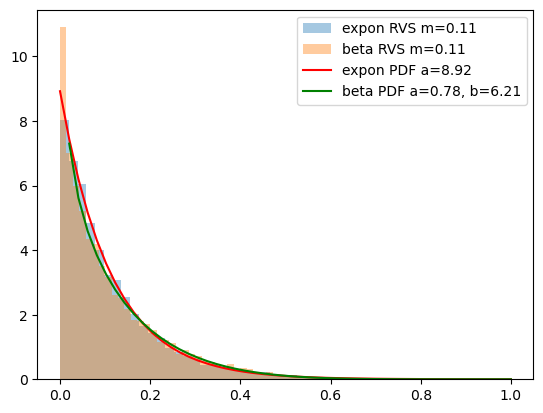

In [57]:
alpha = 8.92
my_rv1 = MyRandomVariableClass(alpha)


alpha1 = 0.78
beta1 = 6.21
my_rv2 = stats.beta(alpha1, beta1)

# sample distribution
samples = my_rv1.rvs(size = 10000)
samples2 = my_rv2.rvs(size = 10000)


# plot histogram of samples
fig, ax1 = plt.subplots()
ax1.hist(list(samples), bins=50, density=True, label=f"expon RVS m={my_rv1.mean():.2f}", alpha=0.4)
ax1.hist(list(samples2), bins=50, density=True, label=f"beta RVS m={my_rv2.mean():.2f}", alpha=0.4)



# plot PDF and CDF of distribution
pts = np.linspace(0, 1)
ax1.plot(pts, my_rv1.pdf(pts), color='red', label=f'expon PDF a={alpha}')
# ax1.plot(pts, my_rv1.cdf(pts), color='orange', label=f'expon CDF a={alpha}')

ax1.plot(pts, my_rv2.pdf(pts), color='green', label=f'beta PDF a={alpha1}, b={beta1}')
# ax1.plot(pts, my_rv2.cdf(pts), color='blue', label=f'beta CDF a={alpha1} b={beta1}')
# ax1.plot(pts, np.exp(-pts*alpha)*alpha + np.exp(-alpha), color='green')

plt.legend()
plt.show()

In [ ]:
R=0.2
n=50
alpha = 0.72
beta = 2.17
confidence = func(R)
expon_alpha=8.92

x0 = get_init_profile(n, alpha, beta, expon_alpha=expon_alpha, ttype=Type.BOTH_BETA)
res_arr, check = HK_2D_sim(x0, confidence, R * 1e-3, 1000)

draw_HK_2D_simulation(res_arr,N=400, R=round(R,2),text='', cmap='plasma')
HK_2D_display_steps(res_arr, text=f'expon distribution a:{expon_alpha:.2f}')

In [ ]:
experiment = consensus_data.index[-1] +1
# experiment=0

simulation_func = HK_2D_sim
count_consensus = 0
CONSENSUS_BORDER = 5
for R in R_array:
    for i in range (len(params_array)):
        alpha = alphas[i]
        beta = betas[i]
        expon_alpha=params_array[i]
        confidence = func(R)
        init_consensus_data(consensus_data, experiment, N, alpha, beta,expon_alpha, R, ttype)
        if count_consensus>=CONSENSUS_BORDER: simulation_func=HK_2D_sim
        print(f"N:{N} R:{R} a:{alpha} b:{beta} func:{simulation_func.__name__} count:{count_consensus}")

        for i in trange(experiments):
            x0 = get_init_profile(N, alpha, beta, ttype=ttype, expon_alpha=expon_alpha)
            res_arr_fast, check_fast = simulation_func(x0, confidence, R * 1e-3, 1000)
            if check_fast:
                cluster_of_agent, cluster_sizes = caln_n_clusters(res_arr_fast[-1, :, :], confidence)
                if ttype ==Type.ONE_BETA or ttype == Type.BOTH_BETA:
                    experiment = consensus_data[
                        ((consensus_data['N'] == N)
                        & (round(consensus_data['alpha'], 2) == round(alpha, 2))
                        & (round(consensus_data['beta'], 2) == round(beta, 2))
                        & (consensus_data['type'] == ttype.value)
                        & (round(consensus_data['eps'], 2) == round(R, 2)))].index[0]
                if ttype == Type.ONE_EXPON or ttype == Type.BOTH_EXPON:
                    experiment = consensus_data[
                        ((consensus_data['N'] == N)
                        & (consensus_data['expon_alpha'] == expon_alpha)
                        & (consensus_data['type'] == ttype.value)
                        & (round(consensus_data['eps'], 2) == round(R, 2)))].index[0]
                if ttype ==Type.BOTH_BETA_EXPON:
                    experiment = consensus_data[
                        ((consensus_data['N'] == N) 
                        & (consensus_data['alpha'] == alpha) 
                        & (consensus_data['beta'] == beta)
                        & (consensus_data['expon_alpha'] == expon_alpha)
                        & (consensus_data['type'] == ttype.value)
                        & (round(consensus_data['eps'],2) == round(R,2)))].index[0]
                consensus_data.at[experiment, "simulation_count"] +=1
                if len(cluster_sizes)==1:
                    # we have consensus
                    count_consensus+=1
                    update_beta_distrib_consensus_data(consensus_data, experiment, res_arr_fast)
            else:
                draw_HK_2D_simulation(res_arr_fast, 'plasma')
        experiment = consensus_data.index[-1] +1

In [67]:
consensus_data

,N,alpha,beta,eps,expon_alpha,consensus_x,consensus_y,consensus_probabity,simulation_time,type,simulation_count
0,50.0,0.5,0.5,0.15,NaN,0.000000,0.000000,0.0,0.0,ONE_BETA,400.0
1,50.0,1.0,1.0,0.15,NaN,0.000000,0.000000,0.0,0.0,ONE_BETA,800.0
2,50.0,1.5,1.5,0.15,NaN,0.000000,0.000000,0.0,0.0,ONE_BETA,800.0
3,50.0,2.0,2.0,0.15,NaN,0.000000,0.000000,0.0,0.0,ONE_BETA,800.0
4,50.0,2.5,2.5,0.15,NaN,0.000000,0.000000,0.0,0.0,ONE_BETA,800.0
...,...,...,...,...,...,...,...,...,...,...,...
545,50.0,3.0,3.0,1.00,3.0,200.478580,112.558592,400.0,1029.0,BOTH_BETA_EXPON,400.0
546,50.0,3.5,3.5,1.00,3.5,199.323914,101.441737,400.0,964.0,BOTH_BETA_EXPON,400.0
547,50.0,4.0,4.0,1.00,4.0,199.832663,92.463008,400.0,923.0,BOTH_BETA_EXPON,400.0
548,50.0,4.5,4.5,1.00,4.5,199.821196,84.055589,400.0,878.0,BOTH_BETA_EXPON,400.0


In [24]:
alphas.size

10

<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Anastasia\AppData\Local\Temp\ipykernel_26112\4205821094.py:15: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(df['eps'], df['consensus_probabity']/df['simulation_count'], label=f'beta $x^0$: $a$:{round(alpha,2)}|$b$:{round(beta,2)}|$\mu$:{E:0.2f}|$\sigma^2$:{sigma:.2f}', c=color, marker="s" )
C:\Users\Anastasia\AppData\Local\Temp\ipykernel_26112\4205821094.py:15: Synta

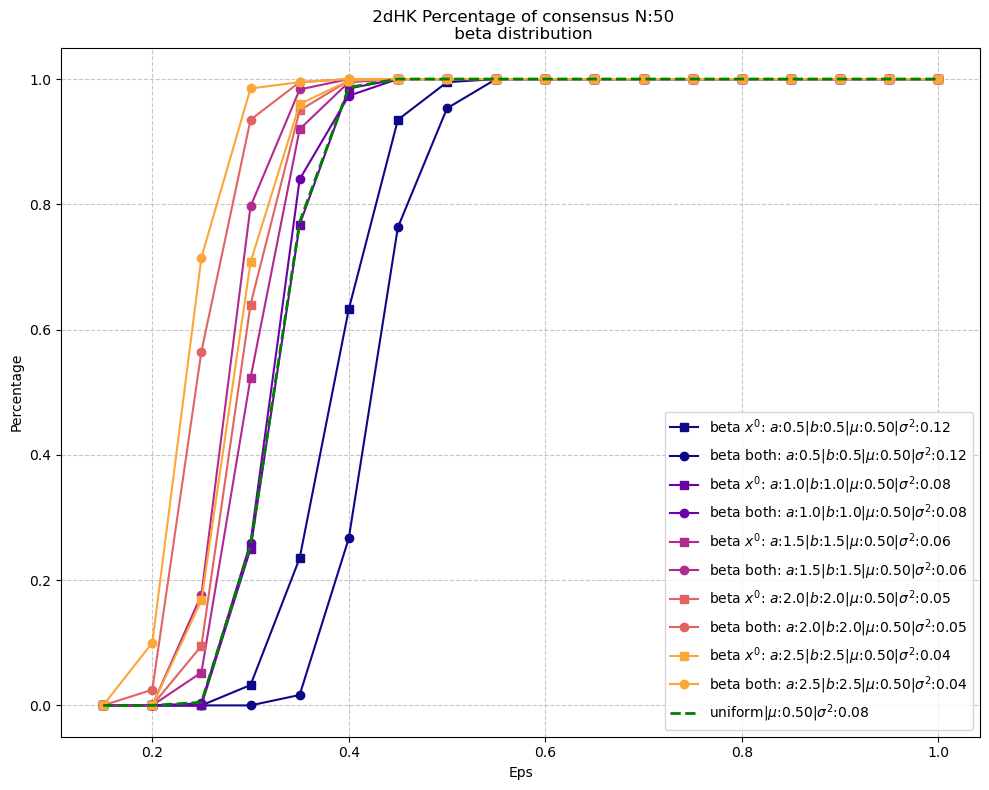

In [68]:
plt.figure(figsize=(10, 8))
k = 2

cmap = mp.cm.get_cmap("plasma")
norm=plt.Normalize(vmin=0, vmax=len(alphas[::k]))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
ttype=Type.ONE_BETA.value
# Plot lines for each beta value
for i in range (len(alphas[::k])):
    alpha = alphas[i]
    beta = betas[i]
    df = consensus_data.query('beta==@beta and alpha==@alpha and N == @N and type==@ttype')
    color=np.array(cmap(norm(i)))
    E, sigma = beta_distrib_ab2Esigma(alpha, beta)
    plt.plot(df['eps'], df['consensus_probabity']/df['simulation_count'], label=f'beta $x^0$: $a$:{round(alpha,2)}|$b$:{round(beta,2)}|$\mu$:{E:0.2f}|$\sigma^2$:{sigma:.2f}', c=color, marker="s" )
    
    df = beta_distib_consensus_data.query('beta==@beta and alpha==@alpha and N == @N')
    plt.plot(df['eps'], df['consensus_probabity']/df['simulation_count'], label=f'beta both: $a$:{round(alpha,2)}|$b$:{round(beta,2)}|$\mu$:{E:0.2f}|$\sigma^2$:{sigma:.2f}', c=color, marker="o" )

udf = unif_data.query('N == @N')
E=1/2
sigma=1/12
plt.plot(udf['eps'], udf['consensus_probabity']/udf['simulation_count'], "--g",linewidth=2, label=f'uniform|$\mu$:{E:0.2f}|$\sigma^2$:{sigma:.2f} ' )

# Adding the HK_sample line (you'll need to adjust this based on your actual data)
plt.title(f' 2dHK Percentage of consensus N:{N}\n beta distribution')
plt.xlabel('Eps')
plt.ylabel('Percentage')
plt.legend()
# Add a grid
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [48]:
df = consensus_data.query('expon_alpha==@alpha and N == @N and type==@ttype')
df

,N,alpha,beta,eps,expon_alpha,consensus_x,consensus_y,consensus_probabity,simulation_time,type,simulation_count
194,50.0,NaN,NaN,0.15,2.5,0.000000,0.000000,0.0,0.0,ONE_EXPON,400.0
204,50.0,NaN,NaN,0.20,2.5,0.000000,0.000000,0.0,0.0,ONE_EXPON,400.0
214,50.0,NaN,NaN,0.25,2.5,0.000000,0.000000,0.0,0.0,ONE_EXPON,400.0
224,50.0,NaN,NaN,0.30,2.5,20.777095,35.935032,72.0,627.0,ONE_EXPON,400.0
234,50.0,NaN,NaN,0.35,2.5,66.245592,113.652940,229.0,1482.0,ONE_EXPON,400.0
244,50.0,NaN,NaN,0.40,2.5,98.383528,171.855263,344.0,1795.0,ONE_EXPON,400.0
254,50.0,NaN,NaN,0.45,2.5,109.047471,191.366916,382.0,1713.0,ONE_EXPON,400.0
264,50.0,NaN,NaN,0.50,2.5,117.004787,198.640685,397.0,1606.0,ONE_EXPON,400.0
274,50.0,NaN,NaN,0.55,2.5,119.390588,199.468099,399.0,1554.0,ONE_EXPON,400.0
284,50.0,NaN,NaN,0.60,2.5,118.900020,200.898852,400.0,1375.0,ONE_EXPON,400.0


<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Anastasia\AppData\Local\Temp\ipykernel_26112\1808442062.py:14: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(df['eps'], df['consensus_probabity']/df['simulation_count'], label=f'expon $x^0$: $a$:{round(expon_alpha,2)}|$\mu$:{E:0.2f}|$\sigma^2$:{sigma:.2f}', c=color, marker="s" )
C:\Users\Anastasia\AppData\Local\Temp\ipykernel_26112\1808442062.py:14: SyntaxWarning: inv

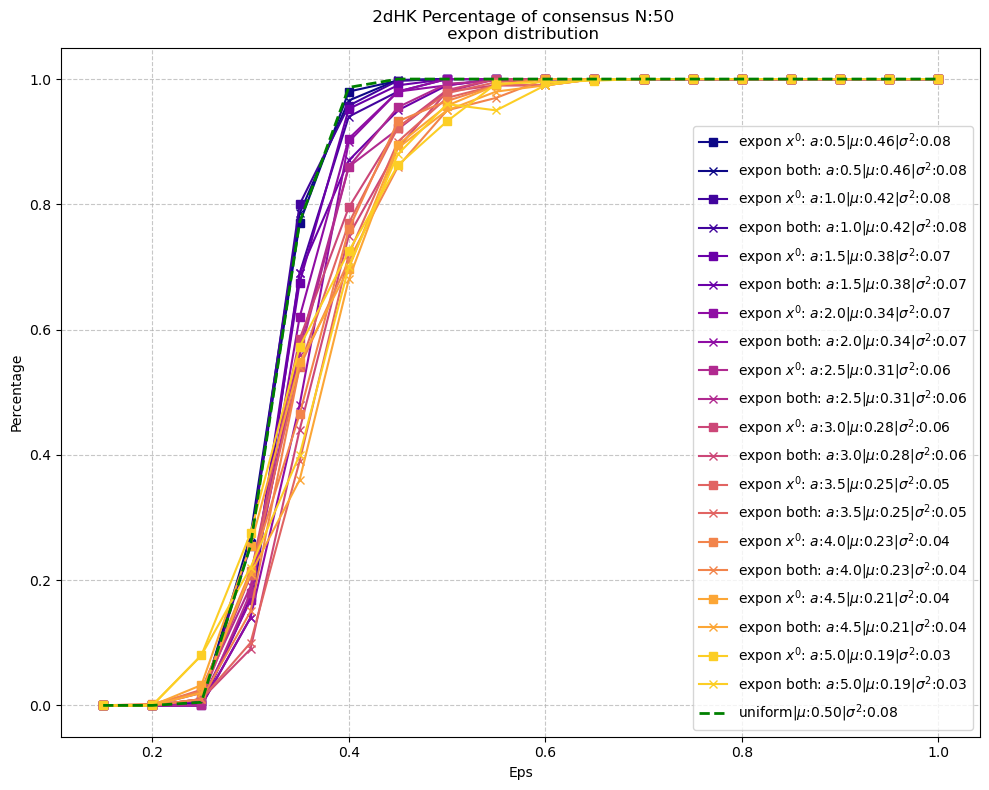

In [71]:
plt.figure(figsize=(10, 8))
k = 1

cmap = mp.cm.get_cmap("plasma")
norm=plt.Normalize(vmin=0, vmax=len(params_array[::k]))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
ttype=Type.ONE_EXPON.value
# Plot lines for each beta value
for i in range (len(params_array[::k])):
    expon_alpha= params_array[i]
    df = consensus_data.query('expon_alpha==@expon_alpha and N == @N and type==@ttype')
    color=np.array(cmap(norm(i)))
    E, sigma = expon_distrib_a2Esigma(expon_alpha)
    plt.plot(df['eps'], df['consensus_probabity']/df['simulation_count'], label=f'expon $x^0$: $a$:{round(expon_alpha,2)}|$\mu$:{E:0.2f}|$\sigma^2$:{sigma:.2f}', c=color, marker="s" )
    
    df = ex_data.query('alpha==@expon_alpha and N == @N')
    plt.plot(df['eps'], df['consensus_probabity']/df['simulation_count'], label=f'expon both: $a$:{round(expon_alpha,2)}|$\mu$:{E:0.2f}|$\sigma^2$:{sigma:.2f}', c=color, marker="x" )

udf = unif_data.query('N == @N')
E=1/2
sigma=1/12
plt.plot(udf['eps'], udf['consensus_probabity']/udf['simulation_count'], "--g",linewidth=2, label=f'uniform|$\mu$:{E:0.2f}|$\sigma^2$:{sigma:.2f} ' )

# Adding the HK_sample line (you'll need to adjust this based on your actual data)
plt.title(f' 2dHK Percentage of consensus N:{N}\n expon distribution')
plt.xlabel('Eps')
plt.ylabel('Percentage')
plt.legend()
# Add a grid
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Anastasia\AppData\Local\Temp\ipykernel_26112\2022988573.py:17: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(df['eps'], df['consensus_probabity']/df['simulation_count'], label=f'expon&beta: $a=b=a_e$:{round(alpha,2)}\n|beta: $\mu$:{E:0.2f}|$\sigma^2$:{sigma:.2f}\n|expon: $\mu$:{E_e:0.2f}|$\sigma^2$:{sigma_e:.2f}', c=color, marker="s" )
C:\Users\Anastasia\AppData\Local

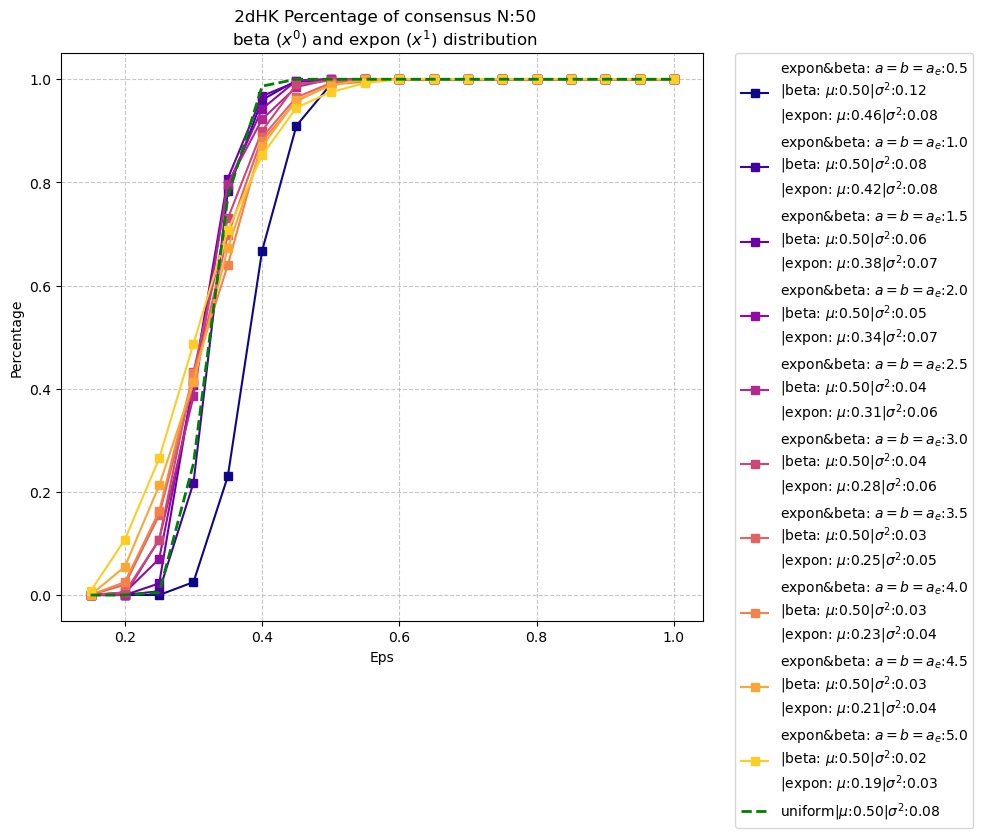

In [82]:
plt.figure(figsize=(10, 8))
k = 1

cmap = mp.cm.get_cmap("plasma")
norm=plt.Normalize(vmin=0, vmax=len(params_array[::k]))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
ttype=Type.BOTH_BETA_EXPON.value
# Plot lines for each beta value
for i in range (len(params_array[::k])):
    expon_alpha= params_array[i]
    alpha = alphas[i]
    beta = betas[i]
    df = consensus_data.query('expon_alpha==@expon_alpha and alpha==@alpha and beta==@beta and N == @N and type==@ttype')
    color=np.array(cmap(norm(i)))
    E, sigma = beta_distrib_ab2Esigma(alpha, beta)
    E_e, sigma_e = expon_distrib_a2Esigma(expon_alpha)
    plt.plot(df['eps'], df['consensus_probabity']/df['simulation_count'], label=f'expon&beta: $a=b=a_e$:{round(alpha,2)}\n|beta: $\mu$:{E:0.2f}|$\sigma^2$:{sigma:.2f}\n|expon: $\mu$:{E_e:0.2f}|$\sigma^2$:{sigma_e:.2f}', c=color, marker="s" )
    
udf = unif_data.query('N == @N')
E=1/2
sigma=1/12
plt.plot(udf['eps'], udf['consensus_probabity']/udf['simulation_count'], "--g",linewidth=2, label=f'uniform|$\mu$:{E:0.2f}|$\sigma^2$:{sigma:.2f} ' )

# Adding the HK_sample line (you'll need to adjust this based on your actual data)
plt.title(f' 2dHK Percentage of consensus N:{N}\n beta ($x^0$) and expon ($x^1$) distribution')
plt.xlabel('Eps')
plt.ylabel('Percentage')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
# Add a grid
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()